<a href="https://colab.research.google.com/github/lukazsw/Machine-Learning-2025L/blob/main/lw430257_homework09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praca domowa: LAB09_MLP

# Autor: Łukasz Wysocki

Celem pracy jest wygenerowanie obrazów „wyśnionych” przez wytrenowaną sieć MNIST.  
Wagi sieci pozostają zamrożone, a optymalizowany jest wyłącznie tensor wejściowy.

Rozwiązuję trzy zadania:

1. Generuję batch 10 obrazów z szumu Gaussowskiego, tak aby sieć klasyfikowała je jako cyfry od 0 do 9.
2. Generuję obrazy podobne jednocześnie do kilku klas.
3. Powtarzam eksperymenty z karą L2 na piksele obrazu i sprawdzam wpływ parametru $\lambda_{L2}$.

Kod jest oparty na modelu MLP wytrenowanym wcześniej w notebooku laboratoryjnym.

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

Working on cpu


In [2]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.1307,), (0.3081,))
])

trainset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=2048,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=1,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 31.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.08MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.78MB/s]


In [3]:
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = torch.nn.ReLU()
        self.flatten = torch.nn.Flatten()
        self.linear1 = torch.nn.Linear(1 * 28 * 28, 1024)
        self.linear2 = torch.nn.Linear(1024, 2048)
        self.linear3 = torch.nn.Linear(2048, 256)
        self.linear4 = torch.nn.Linear(256, 10)
        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.relu(self.linear3(x))
        x = self.linear4(x)
        x = self.dropout(x)
        return x


net = MLP().to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

net.train()
for epoch in range(8):
    running_loss = 0.0

    for batch_inputs, batch_labels in trainloader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        batch_outputs = net(batch_inputs)
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch + 1}: loss = {running_loss / len(trainloader):.4f}")

Epoch 1: loss = 0.6877
Epoch 2: loss = 0.2023
Epoch 3: loss = 0.1313
Epoch 4: loss = 0.0929
Epoch 5: loss = 0.0696
Epoch 6: loss = 0.0537
Epoch 7: loss = 0.0519
Epoch 8: loss = 0.0351


In [4]:
net.eval()
correct = 0
total = 0

with torch.no_grad():
    for test_inputs, test_labels in testloader:
        test_inputs = test_inputs.to(device)
        test_labels = test_labels.to(device)

        test_outputs = net(test_inputs)
        predictions = test_outputs.argmax(dim=1)

        correct += (predictions == test_labels).sum().item()
        total += test_labels.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

for parameter in net.parameters():
    parameter.requires_grad = False

Test accuracy: 0.9820


Model osiąga dokładność testową około 98%, więc można go traktować jako poprawnie nauczony klasyfikator MNIST.

Od tego momentu wagi modelu są zamrożone. W kolejnych eksperymentach optymalizowany będzie tylko tensor wejściowy, czyli sztucznie generowane obrazy.

In [5]:
def denormalize_images(images):
    return images * 0.3081 + 0.1307


def plot_image_batch(images, title):
    images = denormalize_images(images.detach().cpu()).clamp(0, 1)

    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    fig.suptitle(title, fontsize=14)

    for idx, axis in enumerate(axes):
        axis.imshow(images[idx, 0], cmap="gray")
        axis.set_title(str(idx))
        axis.axis("off")

    plt.show()


def plot_confidence_history(confidence_history, title):
    confidence_history = np.array(confidence_history)

    plt.figure(figsize=(10, 6))
    for digit in range(10):
        plt.plot(confidence_history[:, digit], label=str(digit))

    plt.xlabel("Iteration")
    plt.ylabel("Target class probability")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [6]:
def dream_digits(
    model,
    targets,
    steps=1000,
    lr=0.1,
    lambda_l2=0.0,
    save_every=50
):
    model.eval()

    targets = torch.tensor(targets, dtype=torch.long, device=device)
    dreamed_images = torch.randn(len(targets), 1, 28, 28, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([dreamed_images], lr=lr)

    confidence_history = []
    frames = []

    for step in range(steps + 1):
        optimizer.zero_grad()

        logits = model(dreamed_images)
        probabilities = torch.softmax(logits, dim=1)

        classification_loss = torch.nn.functional.cross_entropy(logits, targets)
        l2_loss = lambda_l2 * dreamed_images.pow(2).mean()
        loss = classification_loss + l2_loss

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            target_confidences = probabilities[torch.arange(len(targets)), targets]
            confidence_history.append(target_confidences.detach().cpu().numpy())

            if step % save_every == 0 or step == steps:
                frames.append(dreamed_images.detach().cpu().clone())

    return dreamed_images.detach(), np.array(confidence_history), frames

In [7]:
targets = list(range(10))

dreamed_images, confidence_history, frames = dream_digits(
    model=net,
    targets=targets,
    steps=1000,
    lr=0.1,
    lambda_l2=0.0,
    save_every=50
)

with torch.no_grad():
    logits = net(dreamed_images.to(device))
    probabilities = torch.softmax(logits, dim=1)
    predictions = probabilities.argmax(dim=1).cpu().numpy()
    target_probabilities = probabilities[torch.arange(10), torch.tensor(targets, device=device)].cpu().numpy()

results_task_1 = pd.DataFrame({
    "target": targets,
    "prediction": predictions,
    "target_probability": target_probabilities
})

results_task_1

,target,prediction,target_probability
0,0,0,1.000000
1,1,1,1.000000
2,2,2,1.000000
3,3,3,1.000000
4,4,4,1.000000
5,5,5,1.000000
6,6,6,1.000000
7,7,7,1.000000
8,8,8,0.999996
9,9,9,1.000000


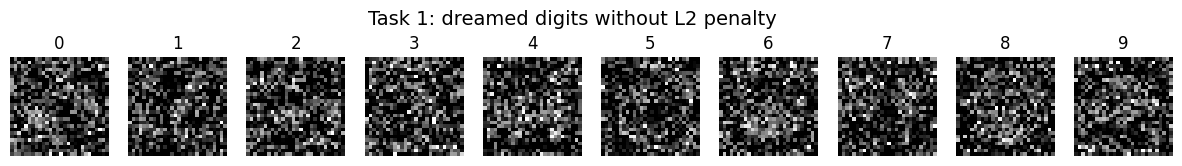

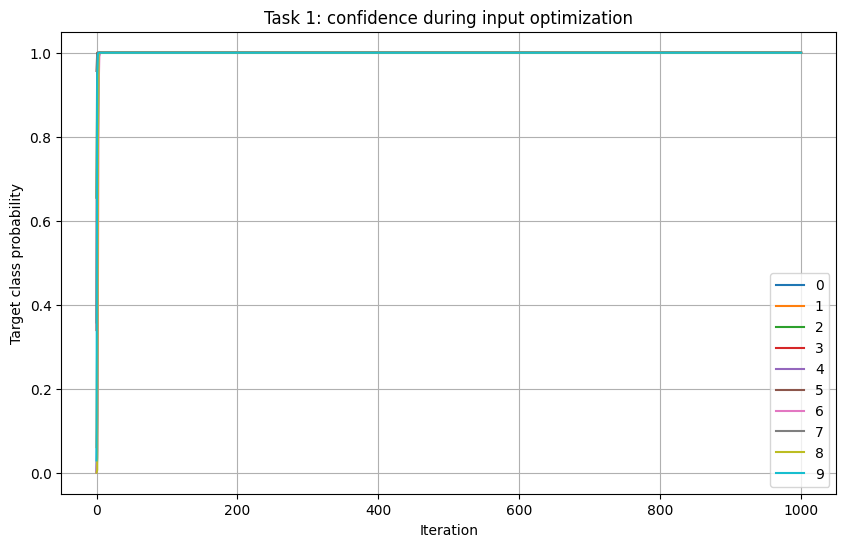

In [8]:
plot_image_batch(dreamed_images, "Task 1: dreamed digits without L2 penalty")
plot_confidence_history(confidence_history, "Task 1: confidence during input optimization")

### Zadanie 1 — obserwacje

Sieć poprawnie rozpoznaje wszystkie wygenerowane obrazy jako zadane klasy $0,1,\ldots,9$ z prawdopodobieństwami bliskimi $1$.

Obrazy nie przypominają jednak rzeczywistych cyfr MNIST. Są głównie wysokoczęstotliwościowym szumem z lokalnymi wzorcami, które silnie aktywują klasyfikator. Wynika to z tego, że optymalizacja maksymalizuje pewność modelu, ale nie wymusza podobieństwa do naturalnych obrazów cyfr. Model nie ma wbudowanego ograniczenia, że wejście musi wyglądać jak ręcznie napisana cyfra — wystarczy, że trafi w cechy, które sieć uznaje za charakterystyczne dla danej klasy.

Wniosek: klasyfikator można łatwo „oszukać” obrazami spoza rozkładu danych treningowych.

In [9]:
def dream_mixed_digits(
    model,
    target_distributions,
    steps=1000,
    lr=0.1,
    lambda_l2=0.0,
    save_every=50
):
    model.eval()

    target_distributions = torch.tensor(target_distributions, dtype=torch.float32, device=device)
    dreamed_images = torch.randn(target_distributions.shape[0], 1, 28, 28, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([dreamed_images], lr=lr)

    confidence_history = []
    frames = []

    for step in range(steps + 1):
        optimizer.zero_grad()

        logits = model(dreamed_images)
        log_probabilities = torch.log_softmax(logits, dim=1)
        probabilities = torch.softmax(logits, dim=1)

        classification_loss = -(target_distributions * log_probabilities).sum(dim=1).mean()
        l2_loss = lambda_l2 * dreamed_images.pow(2).mean()
        loss = classification_loss + l2_loss

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            confidence_history.append(probabilities.detach().cpu().numpy())

            if step % save_every == 0 or step == steps:
                frames.append(dreamed_images.detach().cpu().clone())

    return dreamed_images.detach(), np.array(confidence_history), frames

In [10]:
mixed_targets = torch.zeros(4, 10)

mixed_targets[0, [3, 8]] = 0.5
mixed_targets[1, [4, 9]] = 0.5
mixed_targets[2, [1, 7]] = 0.5
mixed_targets[3, [0, 6]] = 0.5

mixed_images, mixed_confidence_history, mixed_frames = dream_mixed_digits(
    model=net,
    target_distributions=mixed_targets,
    steps=1000,
    lr=0.1,
    lambda_l2=0.0,
    save_every=50
)

with torch.no_grad():
    mixed_logits = net(mixed_images.to(device))
    mixed_probabilities = torch.softmax(mixed_logits, dim=1).cpu().numpy()

mixed_results = pd.DataFrame(
    mixed_probabilities,
    columns=[str(digit) for digit in range(10)]
)

mixed_results

/tmp/ipykernel_14766/2874983945.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_distributions = torch.tensor(target_distributions, dtype=torch.float32, device=device)


,0,1,2,3,4,5,6,7,8,9
0,1.372183e-07,7.445327e-06,1.810952e-05,5.494463e-01,1.506280e-08,1.163220e-07,2.342452e-08,0.000002,4.504973e-01,2.873098e-05
1,2.614948e-05,4.757361e-07,1.382021e-05,2.287064e-08,4.355619e-01,7.566211e-06,1.008130e-05,0.000011,4.655356e-06,5.643643e-01
2,4.658435e-07,4.089098e-01,1.018929e-05,1.754580e-09,8.967383e-06,7.394821e-08,3.769739e-07,0.591070,1.052583e-12,5.443909e-11
3,4.942526e-01,1.271069e-07,1.121888e-08,5.147665e-09,2.401147e-05,3.404774e-06,5.057045e-01,0.000015,1.787213e-07,4.296266e-08


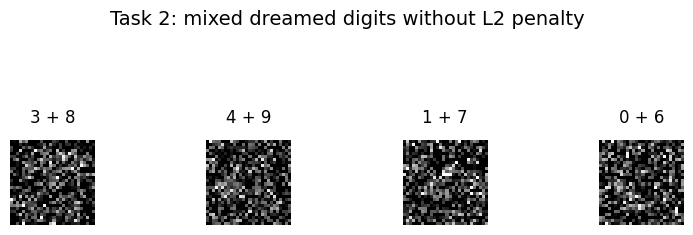

In [12]:
mixed_titles = ["3 + 8", "4 + 9", "1 + 7", "0 + 6"]
images_to_plot = denormalize_images(mixed_images.detach().cpu()).clamp(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(8, 2))
fig.suptitle("Task 2: mixed dreamed digits without L2 penalty", fontsize=14, y=1.15)

for idx, axis in enumerate(axes):
    axis.imshow(images_to_plot[idx, 0], cmap="gray")
    axis.set_title(mixed_titles[idx], pad=12)
    axis.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

### Zadanie 2 — pomysł i obserwacje

Aby wygenerować obraz podobny jednocześnie do kilku cyfr, zamiast jednej klasy docelowej użyłem rozkładu docelowego po klasach.

Przykład: dla obrazu podobnego do $3$ i $8$ przyjąłem target:

$$
p(3)=0.5,\quad p(8)=0.5
$$

a pozostałe klasy mają prawdopodobieństwo $0$.

Funkcja straty wymusza wtedy, aby sieć dzieliła prawdopodobieństwo głównie między wybrane klasy. Wyniki pokazują, że to działa numerycznie: klasyfikator przypisuje wysokie prawdopodobieństwa dwóm zadanym cyfrom.

Wizualnie obrazy nadal są jednak szumowe. Bez dodatkowego ograniczenia optymalizacja nie tworzy naturalnych cyfr, tylko wzorce maksymalizujące odpowiedź modelu.

In [13]:
lambda_values = np.logspace(-3, 1, 5)

l2_results = []
l2_images = {}
l2_histories = {}

for lambda_l2 in lambda_values:
    images, history, _ = dream_digits(
        model=net,
        targets=targets,
        steps=1000,
        lr=0.1,
        lambda_l2=lambda_l2,
        save_every=100
    )

    with torch.no_grad():
        logits = net(images.to(device))
        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1).cpu().numpy()
        target_probabilities = probabilities[torch.arange(10), torch.tensor(targets, device=device)].cpu().numpy()
        image_l2 = images.pow(2).mean().item()

    l2_images[lambda_l2] = images
    l2_histories[lambda_l2] = history

    for digit in range(10):
        l2_results.append({
            "lambda_l2": lambda_l2,
            "target": digit,
            "prediction": predictions[digit],
            "target_probability": target_probabilities[digit],
            "image_l2": image_l2
        })

l2_results_df = pd.DataFrame(l2_results)
l2_results_df

,lambda_l2,target,prediction,target_probability,image_l2
0,0.001,0,0,0.999996,1.210109
1,0.001,1,1,1.000000,1.210109
2,0.001,2,2,1.000000,1.210109
3,0.001,3,3,0.999999,1.210109
4,0.001,4,4,1.000000,1.210109
5,0.001,5,5,1.000000,1.210109
6,0.001,6,6,1.000000,1.210109
7,0.001,7,7,1.000000,1.210109
8,0.001,8,8,0.999999,1.210109
9,0.001,9,9,1.000000,1.210109


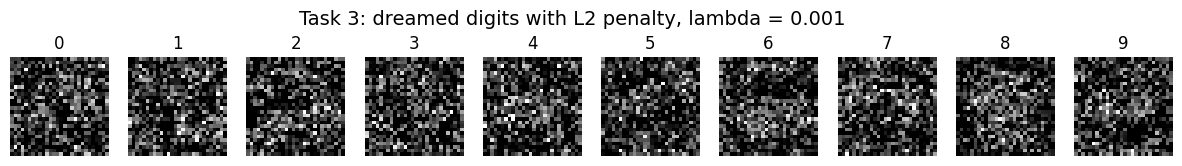

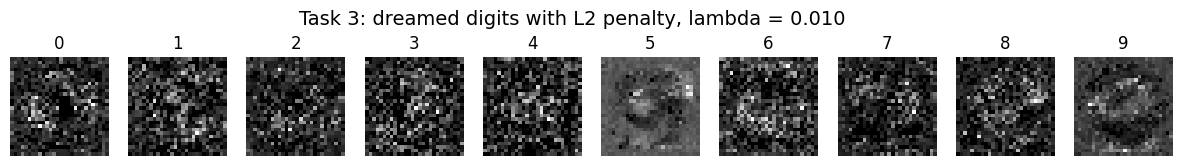

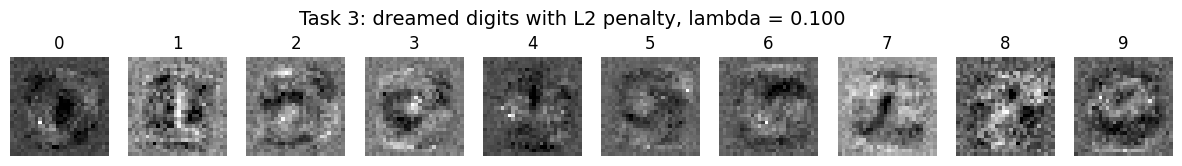

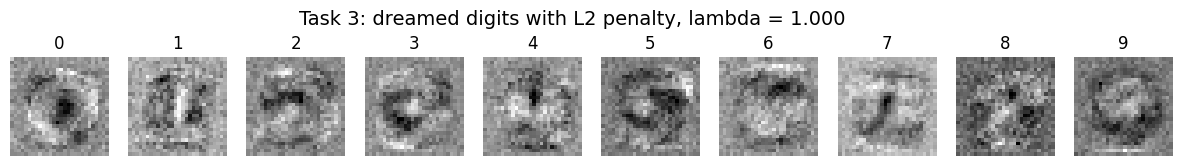

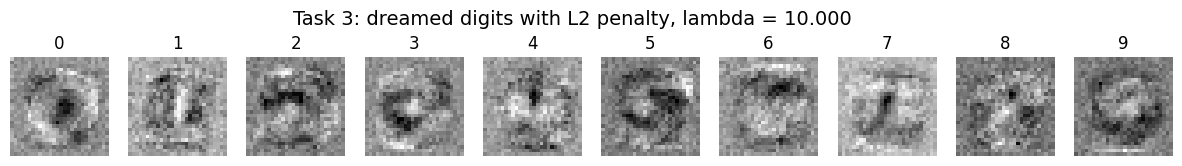

In [14]:
for lambda_l2 in lambda_values:
    plot_image_batch(
        l2_images[lambda_l2],
        f"Task 3: dreamed digits with L2 penalty, lambda = {lambda_l2:.3f}"
    )

In [15]:
l2_summary = l2_results_df.groupby("lambda_l2").agg(
    correct_predictions=("target_probability", lambda x: int((x > 0.5).sum())),
    mean_target_probability=("target_probability", "mean"),
    min_target_probability=("target_probability", "min"),
    image_l2=("image_l2", "mean")
).reset_index()

l2_summary

,lambda_l2,correct_predictions,mean_target_probability,min_target_probability,image_l2
0,0.001,10,0.999999,0.999996,1.210109
1,0.010,10,0.999979,0.999940,0.336909
2,0.100,10,0.999646,0.999404,0.019103
3,1.000,10,0.997278,0.995441,0.010471
4,10.000,10,0.980288,0.967052,0.005769


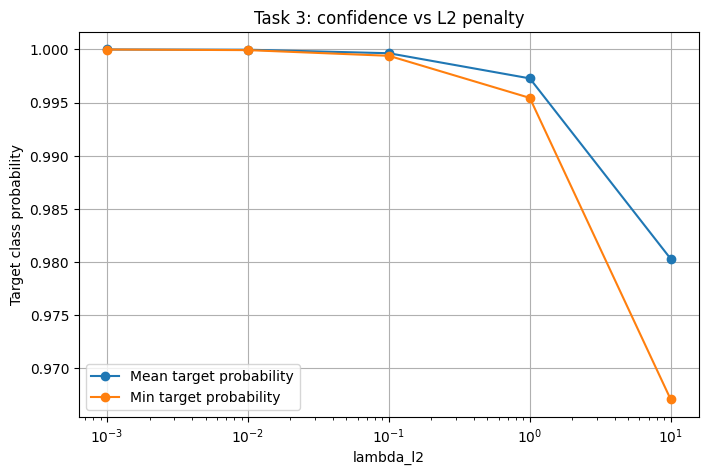

In [17]:
plt.figure(figsize=(8, 5))
plt.semilogx(l2_summary["lambda_l2"], l2_summary["mean_target_probability"], marker="o", label="Mean target probability")
plt.semilogx(l2_summary["lambda_l2"], l2_summary["min_target_probability"], marker="o", label="Min target probability")

plt.xlabel("lambda_l2")
plt.ylabel("Target class probability")
plt.title("Task 3: confidence vs L2 penalty")
plt.legend()
plt.grid()
plt.show()

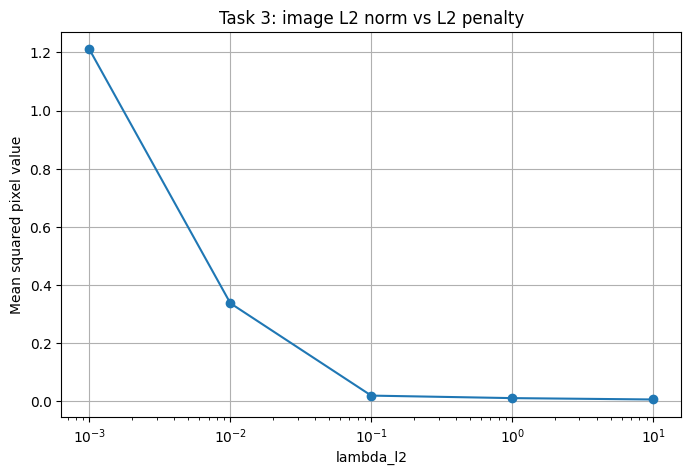

In [18]:
plt.figure(figsize=(8, 5))
plt.semilogx(l2_summary["lambda_l2"], l2_summary["image_l2"], marker="o")

plt.xlabel("lambda_l2")
plt.ylabel("Mean squared pixel value")
plt.title("Task 3: image L2 norm vs L2 penalty")
plt.grid()
plt.show()

### Zadanie 3 — obserwacje

Dla wszystkich testowanych wartości $\lambda_{L2}$ cyfry zostały rozpoznane poprawnie. Nawet przy $\lambda_{L2}=10$ każda klasa ma prawdopodobieństwo większe niż $0.96$.

Wpływ kary L2 jest wyraźny:

- małe wartości $\lambda_{L2}$ dają obrazy bardzo szumowe,
- większe wartości $\lambda_{L2}$ zmniejszają amplitudę pikseli,
- obrazy stają się gładsze i mniej chaotyczne,
- średnia wartość kwadratu pikseli silnie spada wraz ze wzrostem $\lambda_{L2}$,
- pewność klasyfikatora lekko maleje dla dużych wartości $\lambda_{L2}$.

Kara L2 poprawia jakość wizualną względem czystego szumu, ale nie rozwiązuje całego problemu. Obrazy nadal nie wyglądają jak naturalne cyfry MNIST, ponieważ L2 ogranicza tylko wielkość pikseli, a nie wymusza struktury podobnej do prawdziwych cyfr.

In [19]:
mixed_l2_images, mixed_l2_confidence_history, _ = dream_mixed_digits(
    model=net,
    target_distributions=mixed_targets,
    steps=1000,
    lr=0.1,
    lambda_l2=1.0,
    save_every=50
)

with torch.no_grad():
    mixed_l2_logits = net(mixed_l2_images.to(device))
    mixed_l2_probabilities = torch.softmax(mixed_l2_logits, dim=1).cpu().numpy()

mixed_l2_results = pd.DataFrame(
    mixed_l2_probabilities,
    columns=[str(digit) for digit in range(10)]
)

mixed_l2_results

/tmp/ipykernel_14766/2874983945.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_distributions = torch.tensor(target_distributions, dtype=torch.float32, device=device)


,0,1,2,3,4,5,6,7,8,9
0,0.000216,0.003222,0.001161,0.628416,0.000199,0.000522,0.000495,0.001698,0.361555,0.002516
1,0.000330,0.001319,0.000259,0.000187,0.495162,0.001138,0.000392,0.001746,0.000194,0.499274
2,0.000111,0.508564,0.001175,0.000572,0.001136,0.000589,0.000187,0.487632,0.000011,0.000023
3,0.469593,0.000319,0.000320,0.000793,0.000505,0.001161,0.523985,0.002824,0.000080,0.000420


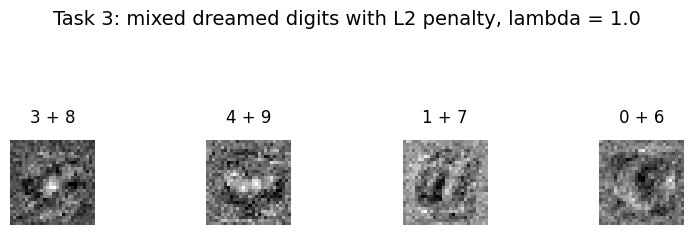

In [20]:
images_to_plot = denormalize_images(mixed_l2_images.detach().cpu()).clamp(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(8, 2))
fig.suptitle("Task 3: mixed dreamed digits with L2 penalty, lambda = 1.0", fontsize=14, y=1.15)

for idx, axis in enumerate(axes):
    axis.imshow(images_to_plot[idx, 0], cmap="gray")
    axis.set_title(mixed_titles[idx], pad=12)
    axis.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

### Zadanie 3 — obrazy podobne do kilku cyfr z karą L2

Po dodaniu kary L2 obrazy mieszane są mniej chaotyczne niż bez regularyzacji. Nadal nie są jednak naturalnymi cyframi MNIST.

Dla par klas:

- $3+8$,
- $4+9$,
- $1+7$,
- $0+6$,

model dzieli prawdopodobieństwo głównie między zadane klasy. Widać więc, że metoda z miękkim rozkładem docelowym działa także z regularyzacją L2.

Kara L2 poprawia stabilność i gładkość obrazu, ale nie wymusza realistycznego kształtu cyfry. Do uzyskania bardziej naturalnych wyników potrzebne byłyby dodatkowe ograniczenia, np. prior obrazu, total variation loss albo generatywny model obrazów MNIST.

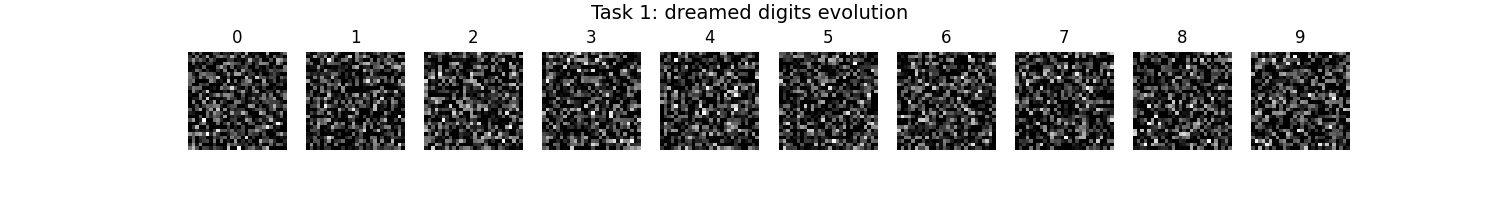

In [21]:
def create_animation(frames, output_path, title):
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    fig.suptitle(title, fontsize=14)

    def update(frame_idx):
        images = denormalize_images(frames[frame_idx]).clamp(0, 1)

        for digit, axis in enumerate(axes):
            axis.clear()
            axis.imshow(images[digit, 0], cmap="gray")
            axis.set_title(str(digit))
            axis.axis("off")

        return axes

    animation = FuncAnimation(fig, update, frames=len(frames), interval=250, blit=False)
    animation.save(output_path, writer=PillowWriter(fps=4))
    plt.close(fig)


create_animation(
    frames=frames,
    output_path="dreamed_digits_task_1.gif",
    title="Task 1: dreamed digits evolution"
)

display(Image(filename="dreamed_digits_task_1.gif"))

### Podsumowanie

W pracy udało się wygenerować obrazy, które wytrenowana sieć MNIST klasyfikuje jako zadane cyfry od $0$ do $9$.

Najważniejsze wnioski:

1. Bez regularyzacji L2 model osiąga prawie stuprocentową pewność klasyfikacji, ale obrazy są szumowe i nie przypominają prawdziwych cyfr.
2. Obrazy podobne do kilku cyfr można generować przez zastosowanie miękkiego rozkładu docelowego, np. $p(3)=0.5$ i $p(8)=0.5$.
3. Kara L2 zmniejsza amplitudę pikseli i poprawia gładkość obrazów.
4. Nawet dla dużej wartości $\lambda_{L2}=10$ klasy są nadal rozpoznawane poprawnie.
5. Sama kara L2 nie wystarcza do uzyskania realistycznych cyfr, ponieważ ogranicza wielkość pikseli, ale nie wymusza struktury typowej dla MNIST.

Wyniki pokazują, że klasyfikator może być bardzo pewny dla obrazów spoza naturalnego rozkładu danych. Optymalizacja wejścia ujawnia więc wzorce, na które sieć reaguje, ale niekoniecznie wzorce zgodne z ludzką intuicją rozpoznawania cyfr.